# 07. Pre-trained audio models: YAMNet with ESC-50

In the previous notebooks, we studied how audio can be represented and analyzed step by step:

```text
waveform → STFT → spectrogram → log-mel spectrogram → MFCCs → feature table → classifier
```

In this notebook, we close the sequence with a pre-trained audio model: **YAMNet**:

https://github.com/tensorflow/models/tree/master/research/audioset/yamnet

The goal is not only to run a model, but to understand the full reasoning path:

```text
read ESC-50 audio
        ↓
show the real ESC-50 label
        ↓
listen to the audio
        ↓
visualize the waveform
        ↓
visualize the log-mel spectrogram
        ↓
load YAMNet
        ↓
show top predicted classes
        ↓
compare and discuss
```

Important note:

YAMNet was trained on AudioSet classes, not specifically on ESC-50 labels.  
Therefore, the comparison between the real ESC-50 label and the YAMNet prediction may be:

```text
exact
semantically close
partially related
confusing
incorrect
```

This makes the notebook useful for discussion.

## Why this notebook comes after Notebook 06

In Notebook 06, we trained our own small classifier using hand-crafted features:

```text
audio file → numerical features → classifier trained by us
```

Here we use a different strategy:

```text
audio file → pre-trained model → predicted sound classes
```

So the contrast is:

```text
Notebook 06 → small supervised model trained on our ESC-50 subset
Notebook 07 → large pre-trained model applied directly to ESC-50 examples
```

## Imports

In [1]:
from pathlib import Path
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import librosa
import librosa.display

from IPython.display import Audio, display

## Project paths

In [2]:
# This cell assumes that the notebook is inside the notebooks/ folder.

NOTEBOOK_DIR = Path.cwd()
PROJECT_ROOT = NOTEBOOK_DIR.parent if NOTEBOOK_DIR.name == "notebooks" else NOTEBOOK_DIR

DATA_DIR = PROJECT_ROOT / "data"
SUBSET_DIR = DATA_DIR / "processed" / "esc50_subset"
SUBSET_AUDIO_DIR = SUBSET_DIR / "audio"
SUBSET_METADATA_PATH = SUBSET_DIR / "esc50_subset_metadata.csv"

print("Project root:", PROJECT_ROOT)
print("Subset metadata:", SUBSET_METADATA_PATH)
print("Subset audio directory:", SUBSET_AUDIO_DIR)

Project root: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class
Subset metadata: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/esc50_subset_metadata.csv
Subset audio directory: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/audio


## Optional plot style

If the repository has a shared plot style file, we use it.  
If not, the notebook will still work with the default Matplotlib style.

In [3]:
SRC_DIR = PROJECT_ROOT / "src"

try:
    if str(SRC_DIR) not in sys.path:
        sys.path.append(str(SRC_DIR))

    from plot_config import (
        apply_plot_style,
        clean_axes,
        GRAYSCALE,
        ACCENT,
        FIGSIZE_WIDE,
        FIGSIZE_TALL,
        DPI,
    )

    apply_plot_style()
    print("Plot style loaded from:", SRC_DIR / "plot_config.py")

except Exception as error:
    print("Using default Matplotlib style.")
    print("Reason:", error)

    FIGSIZE_WIDE = (12, 4)
    FIGSIZE_TALL = (10, 6)
    DPI = 120

    def clean_axes(ax):
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)

    GRAYSCALE = "gray"
    ACCENT = "C0"

Plot style loaded from: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/src/plot_config.py


## Load ESC-50 subset metadata

This notebook uses the reduced ESC-50 subset prepared for class.

If this file is missing, first run:

```bash
python scripts/02_prepare_subset.py
```

In [4]:
if not SUBSET_METADATA_PATH.exists():
    raise FileNotFoundError(
        f"Could not find metadata file: {SUBSET_METADATA_PATH}\n"
        "Please run scripts/02_prepare_subset.py first."
    )

metadata = pd.read_csv(SUBSET_METADATA_PATH)

print("Number of audio files:", len(metadata))
print("Columns:", list(metadata.columns))

metadata.head()

Number of audio files: 80
Columns: ['filename', 'fold', 'target', 'category', 'esc10', 'src_file', 'take', 'subset_audio_path']


,filename,fold,target,category,esc10,src_file,take,subset_audio_path
0,1-100038-A-14.wav,1,14,chirping_birds,False,100038,A,data/processed/esc50_subset/audio/1-100038-A-1...
1,1-34495-A-14.wav,1,14,chirping_birds,False,34495,A,data/processed/esc50_subset/audio/1-34495-A-14...
2,1-34497-A-14.wav,1,14,chirping_birds,False,34497,A,data/processed/esc50_subset/audio/1-34497-A-14...
3,1-38559-A-14.wav,1,14,chirping_birds,False,38559,A,data/processed/esc50_subset/audio/1-38559-A-14...
4,1-38560-A-14.wav,1,14,chirping_birds,False,38560,A,data/processed/esc50_subset/audio/1-38560-A-14...


## Available classes

In [5]:
available_classes = sorted(metadata["category"].unique())

class_counts = (
    metadata["category"]
    .value_counts()
    .sort_index()
    .rename_axis("category")
    .reset_index(name="n_files")
)

print("Available classes:")
for category in available_classes:
    print("-", category)

class_counts

Available classes:
- chirping_birds
- clock_tick
- dog
- helicopter
- keyboard_typing
- rain
- sea_waves
- sneezing


,category,n_files
0,chirping_birds,10
1,clock_tick,10
2,dog,10
3,helicopter,10
4,keyboard_typing,10
5,rain,10
6,sea_waves,10
7,sneezing,10


## Select one ESC-50 example

Choose one class from the list above and one example inside that class.

Try changing:

```python
selected_category = "dog"
example_index_within_class = 0
```

This makes the demo easy to control during class.

In [6]:
selected_category = "dog"
example_index_within_class = 0

examples_from_class = (
    metadata
    .query("category == @selected_category")
    .sort_values("filename")
    .reset_index(drop=True)
)

if len(examples_from_class) == 0:
    raise ValueError(
        f"No examples found for category: {selected_category}. "
        "Choose one category from available_classes."
    )

example_index_within_class = min(example_index_within_class, len(examples_from_class) - 1)
example = examples_from_class.iloc[example_index_within_class]

audio_path = SUBSET_AUDIO_DIR / example["filename"]

if not audio_path.exists():
    raise FileNotFoundError(f"Audio file not found: {audio_path}")

print("Selected ESC-50 real label:", example["category"])
print("Filename:", example["filename"])
print("Audio path:", audio_path)

Selected ESC-50 real label: dog
Filename: 1-100032-A-0.wav
Audio path: /Users/vpoblete/Documents/20230208_vpoblete/20260620_info343_classes/audio-data-mining-class/data/processed/esc50_subset/audio/1-100032-A-0.wav


## Listen to the selected audio

In [7]:
# Load the original audio for listening and visualization.

y_original, sr_original = librosa.load(audio_path, sr=None, mono=True)

print("Original sampling rate:", sr_original)
print("Duration [s]:", len(y_original) / sr_original)

display(Audio(y_original, rate=sr_original))

Original sampling rate: 44100
Duration [s]: 5.0


## Waveform

The waveform shows the sound pressure variation over time.

It is the representation closest to the raw digital audio signal.

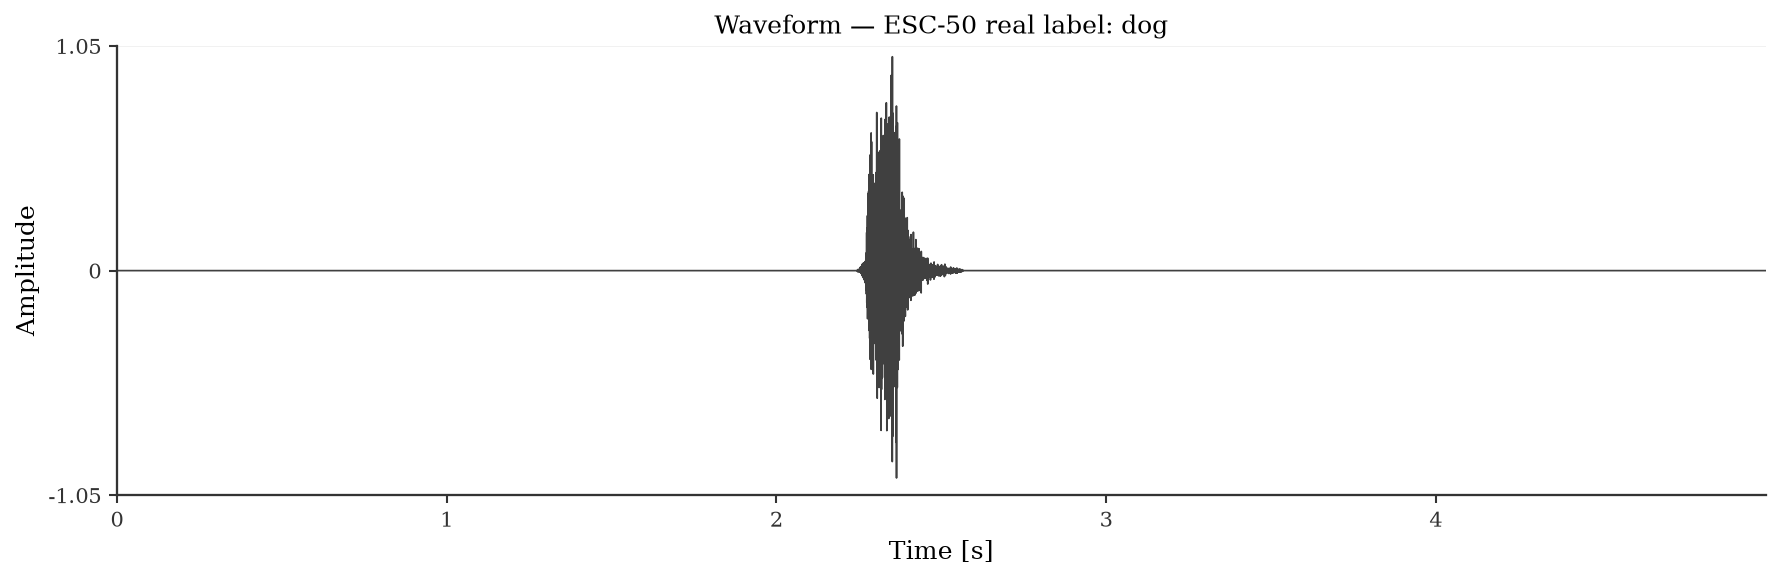

In [8]:
time = np.arange(len(y_original)) / sr_original

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

waveform_color = "0.25"  # grayscale
ax.plot(time, y_original, linewidth=0.8, color=waveform_color)

max_abs_amplitude = np.max(np.abs(y_original))
y_limit = max(1.05 * max_abs_amplitude, 0.05)

ax.set_ylim(-y_limit, y_limit)
ax.set_yticks([-y_limit, 0, y_limit])
ax.set_yticklabels([f"{-y_limit:.2f}", "0", f"{y_limit:.2f}"])
ax.set_xlim(time[0], time[-1])

ax.set_title(f"Waveform — ESC-50 real label: {example['category']}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Amplitude")
ax.grid(True, axis="y", alpha=0.25)
clean_axes(ax)
plt.tight_layout()
plt.show()

## Log-mel spectrogram

YAMNet internally works with log-mel features, but here we compute a log-mel spectrogram ourselves for visualization.

This plot connects directly with the previous notebooks.

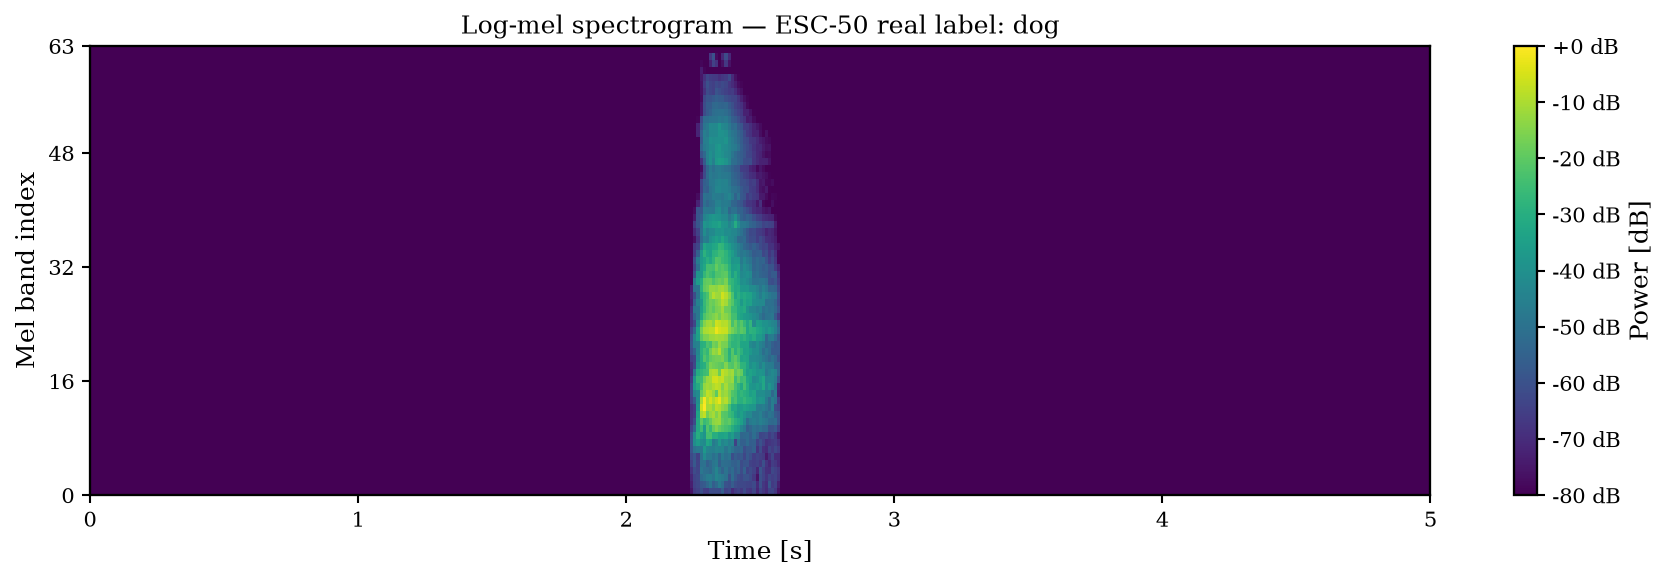

In [9]:
# Compute the log-mel spectrogram for visualization.

n_fft = 1024
hop_length = 512
n_mels = 64

mel_spectrogram = librosa.feature.melspectrogram(
    y=y_original,
    sr=sr_original,
    n_fft=n_fft,
    hop_length=hop_length,
    n_mels=n_mels,
    power=2.0,
)

log_mel_spectrogram = librosa.power_to_db(
    mel_spectrogram,
    ref=np.max,
)

# Plot the log-mel spectrogram using mel-band indices.

fig, ax = plt.subplots(figsize=FIGSIZE_WIDE, dpi=DPI)

duration_s = len(y_original) / sr_original

img = ax.imshow(
    log_mel_spectrogram,
    origin="lower",
    aspect="auto",
    extent=[0, duration_s, 0, n_mels - 1],
    cmap="viridis",
)

ax.set_title(f"Log-mel spectrogram — ESC-50 real label: {example['category']}")
ax.set_xlabel("Time [s]")
ax.set_ylabel("Mel band index")

mel_ticks = [0, 16, 32, 48, n_mels - 1]
ax.set_yticks(mel_ticks)
ax.set_yticklabels([str(tick) for tick in mel_ticks])

fig.colorbar(img, ax=ax, format="%+2.0f dB", label="Power [dB]")
plt.tight_layout()
plt.show()


## Load YAMNet

YAMNet is a pre-trained sound event classifier.

It expects:

```text
mono audio
sampling rate = 16 kHz
floating point values
```

The first time this cell runs, TensorFlow Hub may need internet access to download the model.

If TensorFlow or TensorFlow Hub is not installed, install them in the environment before running this notebook.

In [10]:
try:
    import tensorflow as tf
    import tensorflow_hub as hub

    print("TensorFlow version:", tf.__version__)

except ImportError as error:
    raise ImportError(
        "TensorFlow and TensorFlow Hub are required for this notebook.\n\n"
        "Try installing them in your environment, for example:\n"
        "pip install tensorflow tensorflow_hub\n\n"
        "On Apple Silicon, your existing environment may require a TensorFlow version "
        "compatible with your Python version.\n"
    ) from error

TensorFlow version: 2.21.0


/Users/vpoblete/miniconda3/envs/audio_data_mining/lib/python3.11/site-packages/tensorflow_hub/__init__.py:61: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import parse_version


In [11]:
YAMNET_MODEL_HANDLE = "https://tfhub.dev/google/yamnet/1"

yamnet_model = hub.load(YAMNET_MODEL_HANDLE)

print("YAMNet model loaded.")

YAMNet model loaded.


## Load YAMNet class names

YAMNet predicts AudioSet classes.

We load the class map directly from the TensorFlow models repository.

In [12]:
YAMNET_CLASS_MAP_URL = (
    "https://raw.githubusercontent.com/tensorflow/models/master/"
    "research/audioset/yamnet/yamnet_class_map.csv"
)

yamnet_classes = pd.read_csv(YAMNET_CLASS_MAP_URL)

yamnet_class_names = yamnet_classes["display_name"].to_numpy()

print("Number of YAMNet classes:", len(yamnet_class_names))
yamnet_classes.head()

Number of YAMNet classes: 521


,index,mid,display_name
0,0,/m/09x0r,Speech
1,1,/m/0ytgt,"Child speech, kid speaking"
2,2,/m/01h8n0,Conversation
3,3,/m/02qldy,"Narration, monologue"
4,4,/m/0261r1,Babbling


## Prepare audio for YAMNet

We resample the ESC-50 audio to 16 kHz because this is the sampling rate expected by YAMNet.

In [13]:
yamnet_sr = 16000

y_yamnet, sr_yamnet = librosa.load(
    audio_path,
    sr=yamnet_sr,
    mono=True,
)

# YAMNet expects float32 audio.
waveform_for_yamnet = y_yamnet.astype(np.float32)

print("YAMNet sampling rate:", sr_yamnet)
print("YAMNet waveform shape:", waveform_for_yamnet.shape)
print("Duration [s]:", len(waveform_for_yamnet) / sr_yamnet)

YAMNet sampling rate: 16000
YAMNet waveform shape: (80000,)
Duration [s]: 5.0


## Run YAMNet prediction

YAMNet returns predictions for short audio patches.

The output `scores` has shape:

```text
number_of_patches × number_of_yamnet_classes
```

To summarize the complete audio file, we average the scores over time.

In [14]:
scores, embeddings, spectrogram = yamnet_model(waveform_for_yamnet)

scores_np = scores.numpy()
mean_scores = scores_np.mean(axis=0)

print("scores shape:", scores_np.shape)
print("embeddings shape:", embeddings.numpy().shape)
print("YAMNet internal spectrogram shape:", spectrogram.numpy().shape)

scores shape: (10, 521)
embeddings shape: (10, 1024)
YAMNet internal spectrogram shape: (528, 64)


## Top YAMNet predictions

Now we compare the real ESC-50 label with the top YAMNet classes.

Remember: the label sets are different, so the match may be exact, partial, semantic, or not correct.

In [15]:
top_k = 10

top_indices = np.argsort(mean_scores)[::-1][:top_k]

top_predictions = pd.DataFrame({
    "rank": np.arange(1, top_k + 1),
    "yamnet_class": yamnet_class_names[top_indices],
    "mean_score": mean_scores[top_indices],
})

print("ESC-50 real label:", example["category"])

top_predictions

ESC-50 real label: dog


,rank,yamnet_class,mean_score
0,1,Silence,0.702057
1,2,Dog,0.109556
2,3,"Domestic animals, pets",0.106795
3,4,Animal,0.084838
4,5,Bow-wow,0.080537
5,6,Yip,0.055795
6,7,Bark,0.047650
7,8,Sound effect,0.033988
8,9,Whimper (dog),0.033055
9,10,Howl,0.023321


## Plot top predictions

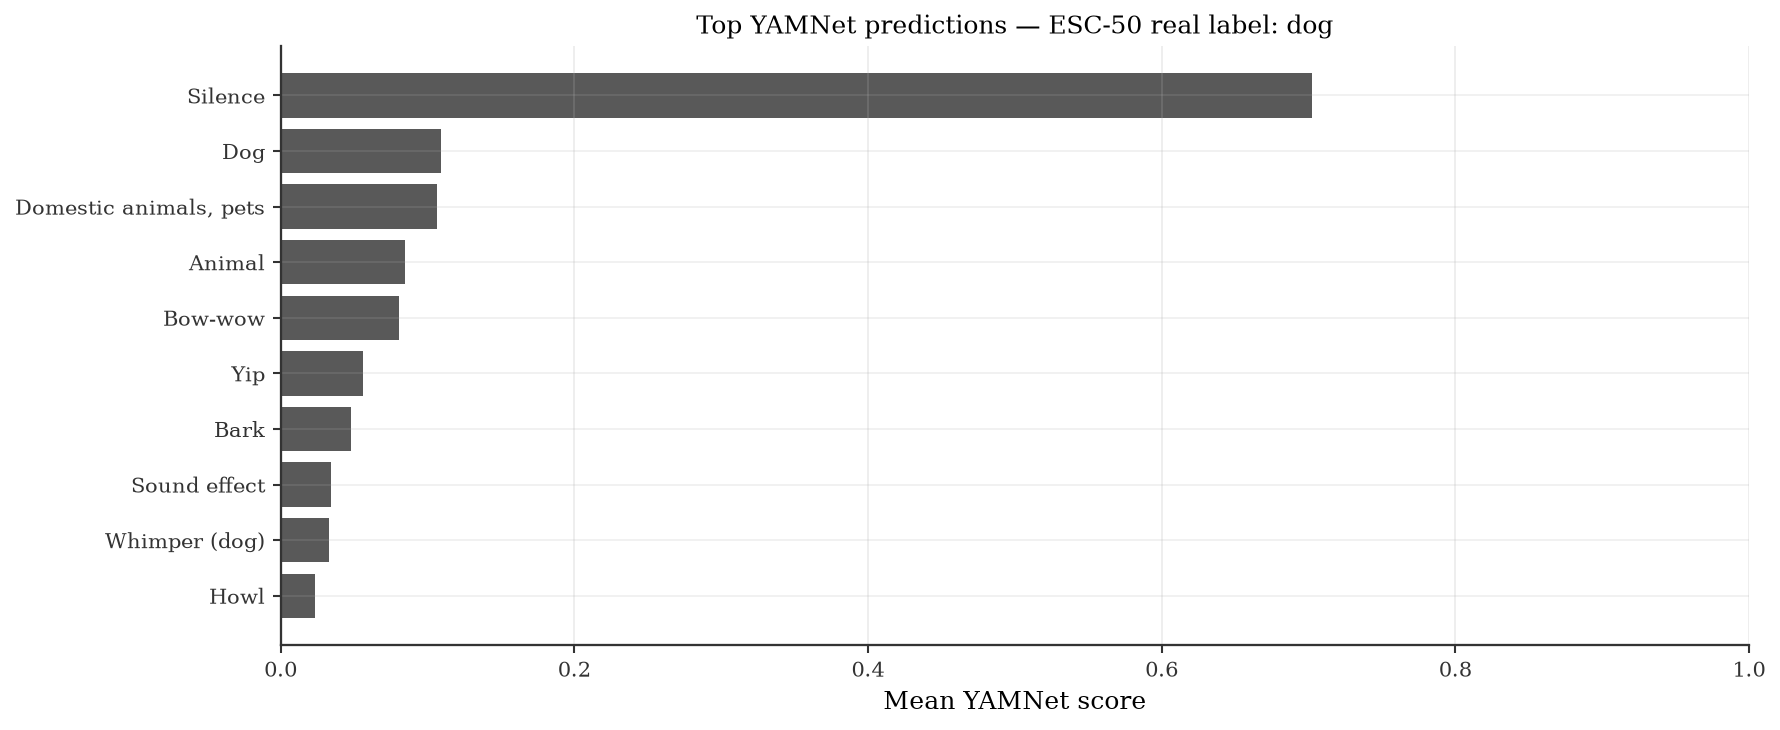

In [16]:
plot_df = top_predictions.iloc[::-1]

fig, ax = plt.subplots(figsize=FIGSIZE_TALL, dpi=DPI)

bar_color = "0.35"  # grayscale
ax.barh(plot_df["yamnet_class"], plot_df["mean_score"], color=bar_color)

ax.set_xlim(0, max(1.0, float(plot_df["mean_score"].max()) * 1.05))
ax.set_xlabel("Mean YAMNet score")
ax.set_title(f"Top YAMNet predictions — ESC-50 real label: {example['category']}")
ax.grid(True, axis="x", alpha=0.25)
clean_axes(ax)
plt.tight_layout()
plt.show()

### Editorial note on the summary plots

For the final visualization, we use a four-panel summary:

```text
1. waveform
2. log-mel spectrogram, shown as mel-band index
3. linear-frequency spectrogram, shown in Hz
4. top YAMNet predicted classes
```

The waveform and prediction bars use grayscale. The spectrograms use the same blue-green colormap (`viridis`) to keep a consistent visual language.

This allows us to compare two complementary views:

```text
log-mel spectrogram           → perceptually motivated frequency representation
linear-frequency spectrogram  → physical frequency scale in Hz
```

## Summary figure: waveform, log-mel spectrogram, and YAMNet predictions

The three most important elements of the demo can be shown together in one figure:

```text
waveform
   ↓
log-mel spectrogram
   ↓
top YAMNet predicted classes
```

This compact visualization is useful for teaching because it connects the audio signal, its time-frequency representation, and the model output in a single view.

In this figure, we use a blue-green colormap (`viridis`) for the log-mel spectrogram.

### Why add a linear-frequency spectrogram?

The log-mel spectrogram and the linear-frequency spectrogram show the same audio from two complementary perspectives:

```text
log-mel spectrogram
    → perceptual frequency organization
    → useful for machine listening models such as YAMNet

linear-frequency spectrogram
    → physical frequency axis in Hz
    → useful for relating the sound to acoustic frequency content
```

In the summary figure, we therefore keep both representations.

/var/folders/yn/m6b_hn8d567fy4sc5wn335th0000gn/T/ipykernel_43423/3639312810.py:136: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


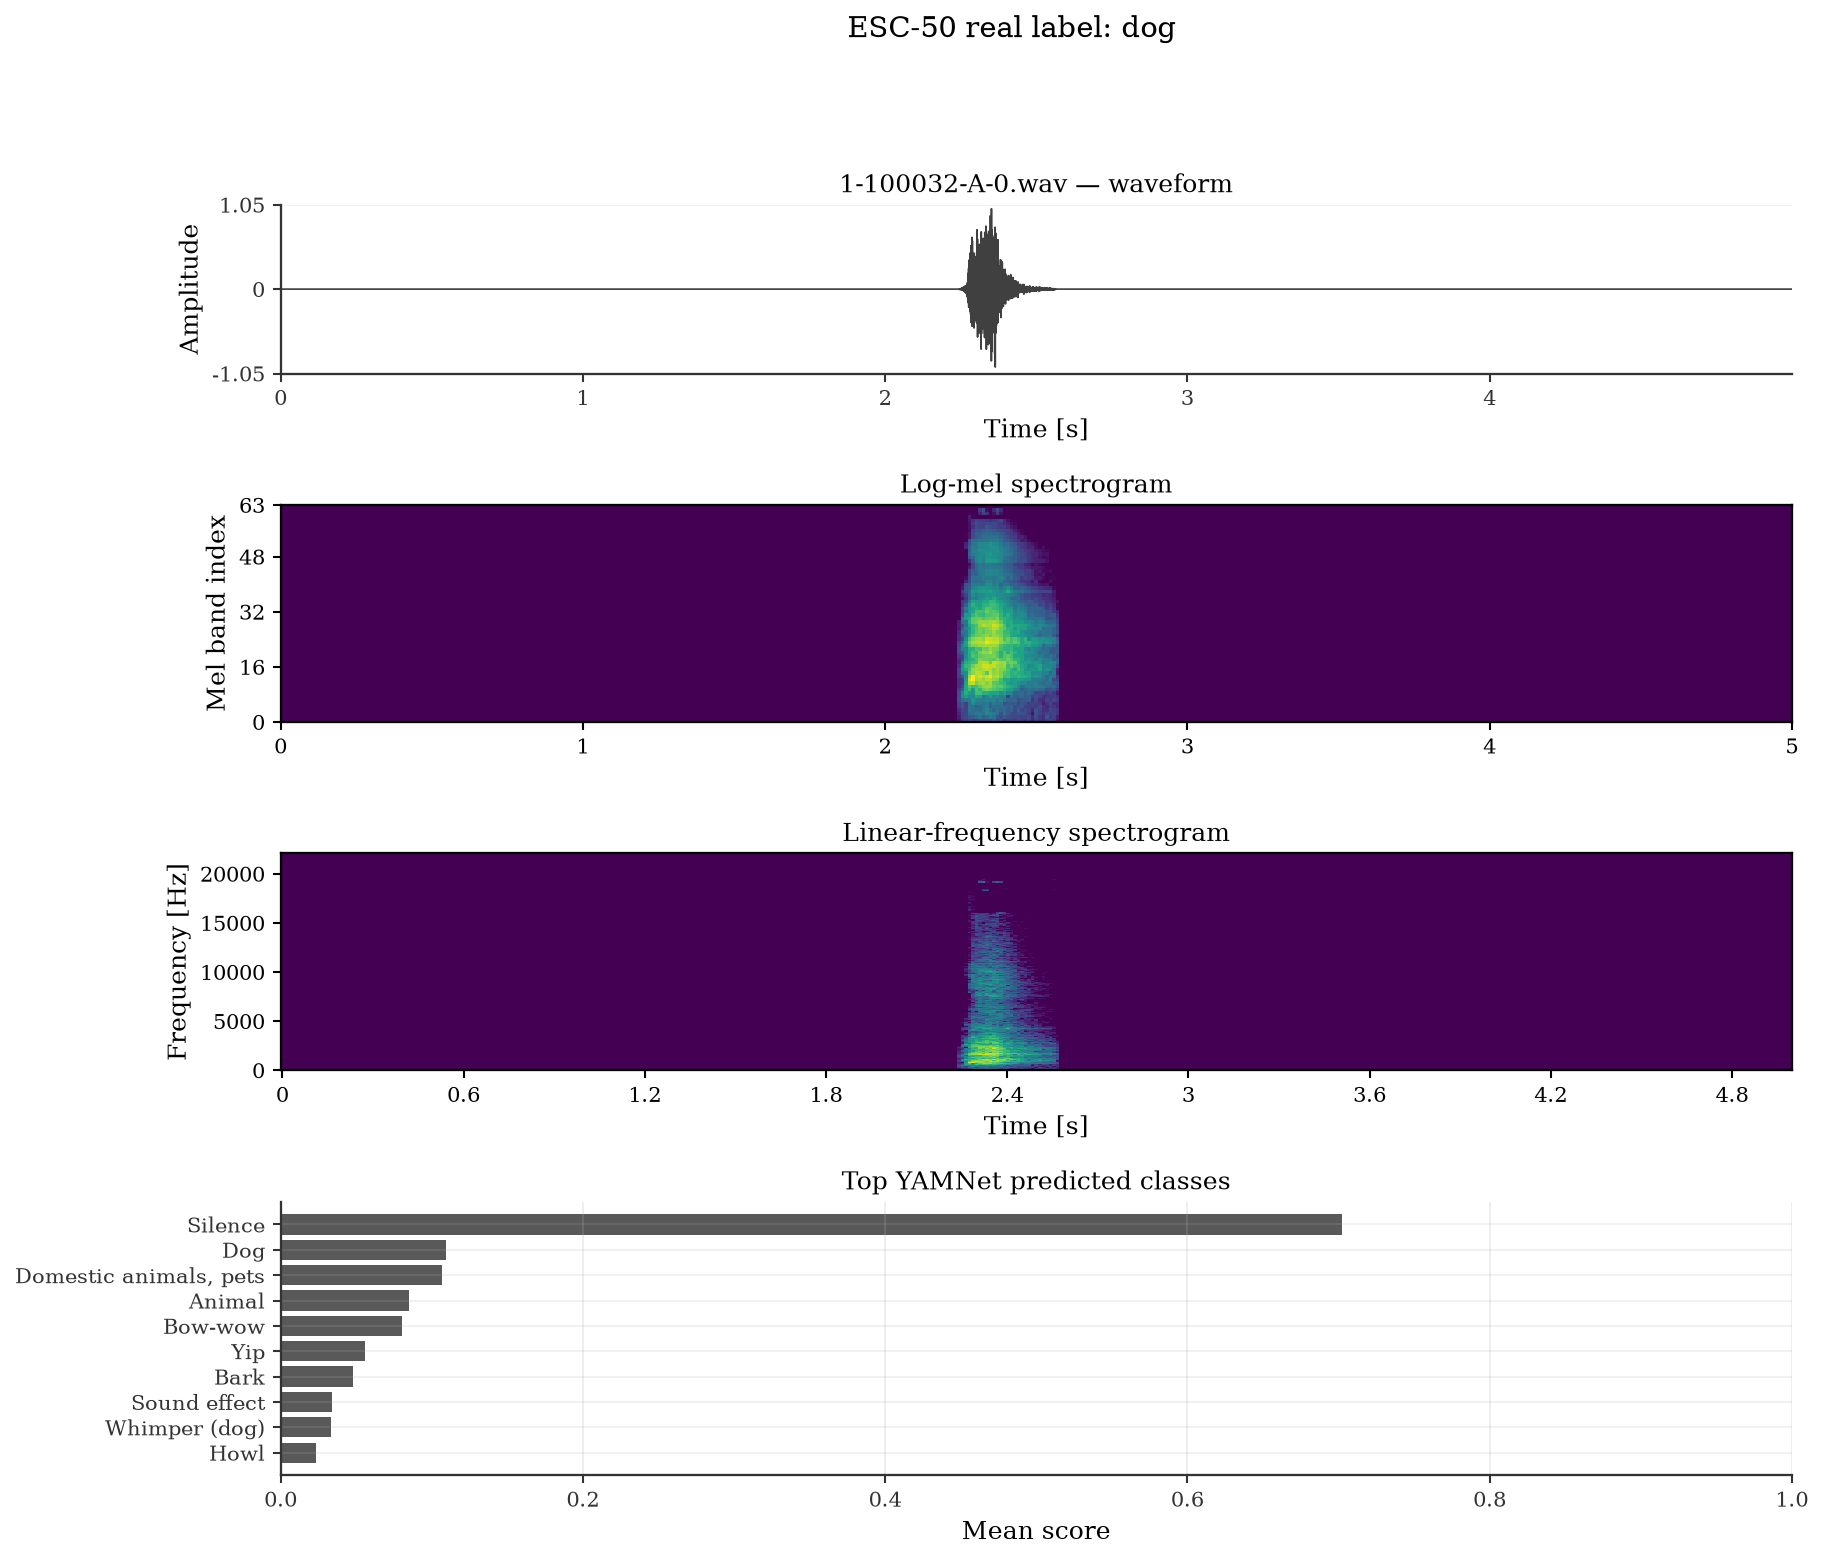

In [17]:
# Safety check: compute the log-mel spectrogram if the previous visualization cell was not executed.

if "log_mel_spectrogram" not in globals():
    n_fft = 1024
    hop_length = 512
    n_mels = 64

    mel_spectrogram = librosa.feature.melspectrogram(
        y=y_original,
        sr=sr_original,
        n_fft=n_fft,
        hop_length=hop_length,
        n_mels=n_mels,
        power=2.0,
    )

    log_mel_spectrogram = librosa.power_to_db(
        mel_spectrogram,
        ref=np.max,
    )

# Compute a linear-frequency spectrogram for comparison.
# This keeps the physical frequency axis in Hz.

linear_spectrogram = np.abs(
    librosa.stft(
        y_original,
        n_fft=n_fft,
        hop_length=hop_length,
        center=True,
    )
) ** 2

log_linear_spectrogram = librosa.power_to_db(
    linear_spectrogram,
    ref=np.max,
)

# yamnet_summary_figure_demo
# Compact summary figure:
# waveform + log-mel spectrogram + linear-frequency spectrogram + top YAMNet predictions.

summary_top_k = 10
summary_top_predictions = top_predictions.head(summary_top_k).copy()

# Reverse order only for horizontal plotting, so the highest score appears at the top.
plot_predictions = summary_top_predictions.iloc[::-1]

time_original = np.arange(len(y_original)) / sr_original
duration_s = len(y_original) / sr_original

waveform_color = "0.25"  # grayscale: dark gray
bar_color = "0.35"       # grayscale: medium-dark gray

fig, axes = plt.subplots(
    nrows=4,
    ncols=1,
    figsize=(13, 11),
    dpi=DPI,
    gridspec_kw={
        "height_ratios": [1.05, 1.35, 1.35, 1.7],
        "hspace": 0.60,
    },
)

# 1) Waveform
axes[0].plot(time_original, y_original, linewidth=0.8, color=waveform_color)

max_abs_amplitude = np.max(np.abs(y_original))
y_limit = max(1.05 * max_abs_amplitude, 0.05)

axes[0].set_ylim(-y_limit, y_limit)
axes[0].set_yticks([-y_limit, 0, y_limit])
axes[0].set_yticklabels([f"{-y_limit:.2f}", "0", f"{y_limit:.2f}"])
axes[0].set_xlim(time_original[0], time_original[-1])

axes[0].set_title(f"{example['filename']} — waveform")
axes[0].set_xlabel("Time [s]")
axes[0].set_ylabel("Amplitude")
axes[0].grid(True, axis="y", alpha=0.25)
clean_axes(axes[0])

# 2) Log-mel spectrogram, with mel-band index
axes[1].imshow(
    log_mel_spectrogram,
    origin="lower",
    aspect="auto",
    extent=[0, duration_s, 0, n_mels - 1],
    cmap="viridis",
)

axes[1].set_title("Log-mel spectrogram")
axes[1].set_xlabel("Time [s]")
axes[1].set_ylabel("Mel band index")

mel_ticks = [0, 16, 32, 48, n_mels - 1]
axes[1].set_yticks(mel_ticks)
axes[1].set_yticklabels([str(tick) for tick in mel_ticks])

# 3) Linear-frequency spectrogram, with y-axis in Hz
librosa.display.specshow(
    log_linear_spectrogram,
    sr=sr_original,
    hop_length=hop_length,
    x_axis="time",
    y_axis="linear",
    cmap="viridis",
    ax=axes[2],
)

axes[2].set_title("Linear-frequency spectrogram")
axes[2].set_xlabel("Time [s]")
axes[2].set_ylabel("Frequency [Hz]")

# 4) Top YAMNet predictions
axes[3].barh(
    plot_predictions["yamnet_class"],
    plot_predictions["mean_score"],
    color=bar_color,
)

x_limit = max(1.0, float(plot_predictions["mean_score"].max()) * 1.05)
axes[3].set_xlim(0, x_limit)
axes[3].set_title("Top YAMNet predicted classes")
axes[3].set_xlabel("Mean score")
axes[3].set_ylabel("")
axes[3].grid(True, axis="x", alpha=0.25)
clean_axes(axes[3])

fig.suptitle(
    f"ESC-50 real label: {example['category']}",
    y=0.995,
    fontsize=14,
)

plt.tight_layout()
plt.show()


## A compact comparison table

This table places the real ESC-50 label next to the strongest YAMNet prediction.

In [18]:
comparison = pd.DataFrame([
    {
        "filename": example["filename"],
        "esc50_real_label": example["category"],
        "top_yamnet_prediction": top_predictions.loc[0, "yamnet_class"],
        "top_yamnet_score": top_predictions.loc[0, "mean_score"],
    }
])

comparison

,filename,esc50_real_label,top_yamnet_prediction,top_yamnet_score
0,1-100032-A-0.wav,dog,Silence,0.702057


## Conceptual interpretation table

The goal of this notebook is not only to check whether YAMNet is *right* or *wrong*.

A more useful question is:

> How is the YAMNet prediction related to the real ESC-50 label?

Sometimes the prediction is almost exact.  
Sometimes it is broader but semantically related.  
Sometimes a short event is hidden by silence when we average predictions over the whole audio file.

The following table summarizes typical cases that can be discussed in class.

In [20]:
# conceptual_interpretation_table_demo
# Conceptual examples for discussing YAMNet predictions on ESC-50 sounds.

conceptual_interpretation_table = pd.DataFrame(
    [
        {
            "ESC-50 real label": "keyboard_typing",
            "Typical YAMNet output": "Typing / Computer keyboard / Clicking",
            "Interpretation": "Almost exact match",
            "Learning point": "The waveform and log-mel spectrogram show many repeated impulsive events.",
        },
        {
            "ESC-50 real label": "rain",
            "Typical YAMNet output": "Water / Rain / Rain on surface / Raindrop",
            "Interpretation": "Semantically correct, but sometimes broader",
            "Learning point": "YAMNet may predict a more general class such as Water before the more specific class Rain.",
        },
        {
            "ESC-50 real label": "chirping_birds",
            "Typical YAMNet output": "Animal / Bird / Bird vocalization / Chirp, tweet",
            "Interpretation": "Hierarchical or semantically close prediction",
            "Learning point": "The most general class may appear first, while the more specific bird-related classes appear below.",
        },
        {
            "ESC-50 real label": "helicopter",
            "Typical YAMNet output": "Vehicle / Engine / Idling / Vibration",
            "Interpretation": "Related sound source, but not exact",
            "Learning point": "The model captures engine and vehicle-like acoustic content even if it does not output Helicopter as top-1.",
        },
        {
            "ESC-50 real label": "sneezing",
            "Typical YAMNet output": "Silence / Cough / Speech / Sneeze",
            "Interpretation": "Short event can be dominated by silence",
            "Learning point": "Averaging predictions over time can hide brief events when most of the audio is silent.",
        },
    ]
)

conceptual_interpretation_table

,ESC-50 real label,Typical YAMNet output,Interpretation,Learning point
0,keyboard_typing,Typing / Computer keyboard / Clicking,Almost exact match,The waveform and log-mel spectrogram show many...
1,rain,Water / Rain / Rain on surface / Raindrop,"Semantically correct, but sometimes broader",YAMNet may predict a more general class such a...
2,chirping_birds,"Animal / Bird / Bird vocalization / Chirp, tweet",Hierarchical or semantically close prediction,"The most general class may appear first, while..."
3,helicopter,Vehicle / Engine / Idling / Vibration,"Related sound source, but not exact",The model captures engine and vehicle-like aco...
4,sneezing,Silence / Cough / Speech / Sneeze,Short event can be dominated by silence,Averaging predictions over time can hide brief...


### Lecture interpretation

A useful way to guide the discussion is:

```text
exact match
    ↓
semantically close prediction
    ↓
broader category
    ↓
related but not exact sound source
    ↓
limitation caused by silence or temporal averaging
```

This helps to understand that model predictions are not only labels.  
They are also a way to discuss how a model organizes sound information.

A useful closing sentence is:

> YAMNet does not always return the same label as ESC-50, but many predictions are acoustically or semantically related. This is expected because YAMNet was trained with a different label vocabulary.

## Discussion questions

Use this final notebook to discuss:

1. Does the top YAMNet class match the ESC-50 label exactly?
2. If not, is it semantically close?
3. Does the waveform help explain the sound?
4. Does the log-mel spectrogram show visible structure related to the sound?
5. Why can a pre-trained model work on a dataset it was not trained on?
6. Why is this not the same as training our own classifier on ESC-50?

A useful closing idea:

```text
hand-crafted features → interpretable descriptors designed by us
pre-trained model     → learned representation from a large external dataset
```

Both approaches are valuable in audio data mining.

## Optional exercise

Try several ESC-50 classes:

```python
selected_category = "dog"
selected_category = "chirping_birds"
selected_category = "rain"
selected_category = "helicopter"
selected_category = "keyboard_typing"
```

For each one, discuss whether the top YAMNet predictions are:

```text
correct
semantically related
confusing
unexpected
```